(ch:linear-correlation)=
# 선형 상관관계

**선형 상관관계 종류**

데이터 분석 과정에서 가장 자주 마주치는 질문 중 하나는 "두 데이터가 서로 얼마나 밀접하게 연관되어 있는가?"이다.
이때 한 데이터의 값이 커짐에 따라 다른 데이터의 값도 일정한 비율로 증가(양의 상관관계)하거나 감소(음의 상관관계)하는 직선 형태의 경향성을 선형 상관관계<font size='2'>linear correlation</font>라고 부른다.

일반적으로 두 데이터 사이의 선형 상관관계 여부를 파악하는 것으로 분석을 시작하며, 이러한 연관성의 유무와 강도를 객관적으로 측정하는 척도로 공분산<font size='2'>covariance</font>과 상관계수<font size='2'>correlation coefficient</font>가 주로 활용된다.

**기본 설정**

탐색적 데이터분석(EDA)에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 선형 상관관계

**선형 상관관계 종류**

두 데이터 사이의 선형 상관관계는 크게 세 가지로 나눌 수 있다.

1. 양(+)의 선형 상관관계: 한 데이터의 값이 증가할 때 다른 데이터의 값도 증가하는 경향. (예: 운동 시간과 근육량)
2. 음(-)의 선형 상관관계: 한 데이터의 값이 증가할 때 다른 데이터의 값은 감소하는 경향. (예: 자동차 무게와 연비)
3. 선형 상관관계 미약 또는 없음: 산점도에서 직선 형태의 관계를 찾기 힘든 경우.

**데이터셋 불러오기**

설명을 위해 성인 남녀 1,000명(여성 500명, 남성 500명)의 신체 정보를 담고 있으며, 6개의 특성 데이터로 구성된
`body_fat.csv` 파일을 활용한다.
| 데이터 | 설명 | 타입 |
|------|------|------|
| `ID` | 샘플 고유 식별자 (F001~F500: 여성, M001~M500: 남성) | 문자열 |
| `Sex` | 성별 (F: 여성, M: 남성) | 범주형 |
| `Age` | 나이 (세) | 수치형 |
| `Height` | 키 (cm) | 수치형 |
| `Weight` | 몸무게 (kg) | 수치형 |
| `Body fat percentage` | 체지방률 (%) | 수치형 |

언급된 데이터셋을 `ID` 특성을 행 인덱스로 지정하면서 데이터프레임으로 불러온다.

In [4]:
body_df = pd.read_csv(data_url + "body_fat.csv", index_col='ID')
body_df

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


`Body fat percentage`와 같이 띄어쓰기가 포함된 긴 열의 이름을 간결한 이름인 `BFP`로 변경한다. 열의 이름이 수정된 새로운 데이터프레임을 기존 변수에 재할당하는 방식으로 사용한다.

`Sex` 특성만 문자열로 구성되었다. 즉 범주형 특성이다.
나머지 특성은 모두 부동소수점 자료형을 갖는다. 즉 수치형 특성이다.

In [5]:
body_df = body_df.rename(columns={'Body fat percentage': 'BFP'})
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     1000 non-null   str    
 1   Age     1000 non-null   float64
 2   Height  1000 non-null   float64
 3   Weight  1000 non-null   float64
 4   BFP     1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


## 상관관계와 산점도

`body_df` 데이터프레임에 특성으로 포함된 데이터들 사이의 상관관계를 
산점도<font size='2'>scatter plot</font>를 이용하여 확인해 본다.
양(+), 음(-), 그리고 선형 상관관계 미약를 보여주는 특성들이 모두 보여진다.

**양의 상관관계: 키(`Height`) vs 몸무게(`Weight`)**

<Axes: xlabel='Height', ylabel='Weight'>

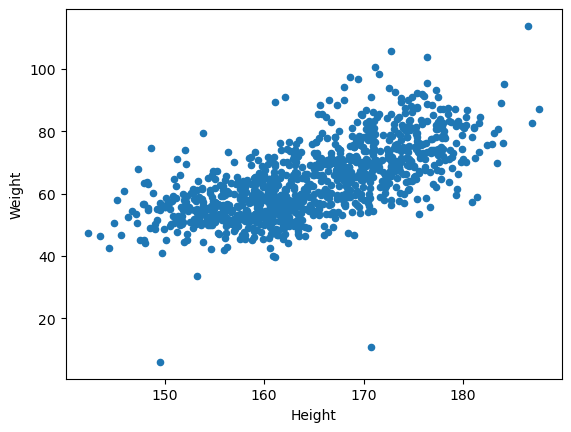

In [6]:
body_df.plot.scatter(x='Height', y='Weight')

**참고: 이상치 여부 판단**

위 산점도에 키가 150cm 또는 170cm 정도이지만 몸무게는 채 20kg이 되지 않는 사례가 두 개 보인다.
실제로 그런 사람이 있을 확률이 매우 낮기에 입력 오류, 즉 이상치일 가능성이 높다.
그리고 실제 존재하는 사례라 하더라도 나머지 사례들과 차이가 너무 크기에 이상치로 간주해야 한다.

위 두 사례는 몸무게에 대한 IQR 기준으로도 이상치에 해당한다.
다만 아래 상자그림에서 보여지듯이 몸무게의 IQR 기준으로만 보았을 때는 100kg 이상의 사례들도 이상치로 간주되는 반면에,
위 산점도에서는 20kg 이하의 몸무게 사례만 이상치로 보인다.

이처럼 데이터 샘플의 이상치 여부는 다양한 기준으로 확인해야 한다.

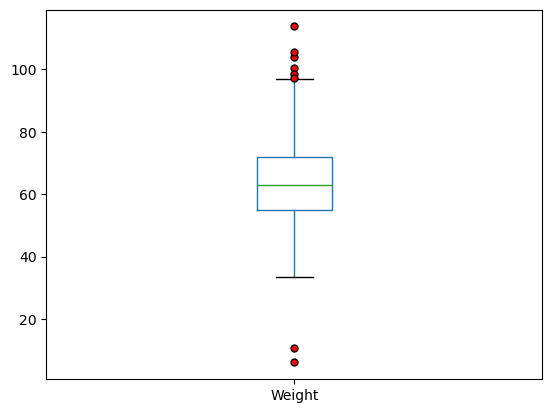

In [7]:
body_df.boxplot(
    column=['Weight'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

**음의 상관관계: 키(`Height`) vs 체지방률(`BFP`)**

<Axes: xlabel='Height', ylabel='BFP'>

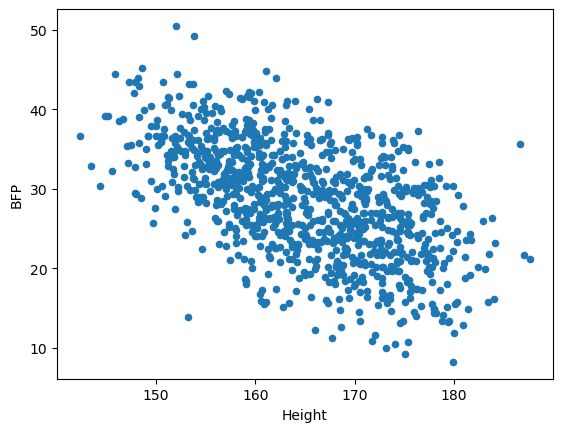

In [8]:
body_df.plot.scatter(x='Height', y='BFP')

**선형 상관관계 매우 미약: 나이(`Age`) vs 몸무게(`Weight`)**

<Axes: xlabel='Age', ylabel='Weight'>

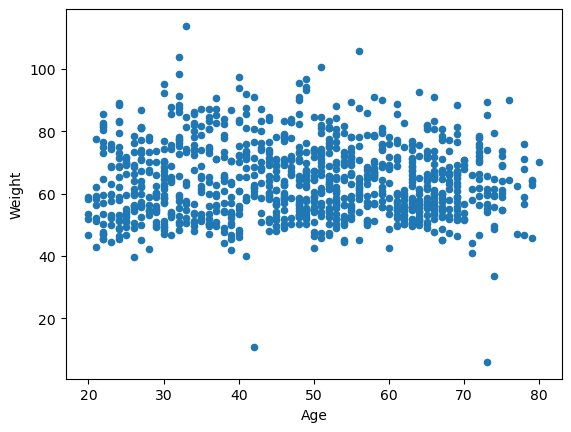

In [9]:
body_df.plot.scatter(x='Age', y='Weight')

선형 상관관계를 
**공분산**<font size='2'>covariance</font>과 
**상관계수**<font size='2'>correlation coefficient</font> 두 개의 척도를 통해 수치화할 수 있다.
먼저 공분산을 소개한다.

## 상관관계 vs 인과관계 

데이터를 분석할 때 산점도를 무시하고 통계치(상관계수) 절댓값 하나만 맹신하거나 관계의 본질을 오해하는 경우가 빈번하다. 특히 상관관계를 인과관계로 오해하는 실수가 자주 발생한다.

> 상관관계가 높다고 해서 반드시 두 데이터 사이의 원인과 결과의 인과성이 보장되는 것은 아니다. 제3의 변수(교란 변수)가 두 변수(데이터) 모두에 영향을 미치는 허위 상관관계일 수 있다.

**양의 허위 상관관계 사례**

* 사례 1. 황새 무리 수와 신생아 출생률:
  * 통계학자인 로버트 매튜스(Robert Matthews)가 연구하여 발표한 실제 데이터 기반 사례다. 17개 유럽 국가 통계를 확인한 결과 국가별 '황새 둥지 수'와 '신생아 출생 수' 사이에 매우 강한 양(+)의 상관관계가 나타났다.
  * 진범(제3의 변수): 국가의 영토 크기와 인구수. 영토가 큰 국가일수록 자연환경이 넓어 황새가 많이 서식하며, 동시에 모수가 되는 인구수 자체도 많아 신생아 수도 많은 것이다. 즉, 황새가 아기를 물어다 주는 것(인과관계)이 아니다.
  
* 사례 2. 발 크기와 어휘력 수준:
  * 통계 입문서에서 자주 쓰이는 사례로 초등학생을 대상으로 조사한 결과, '발 크기'가 큰 학생일수록 시험에서 '독해력(어휘력)' 점수가 높게 측정되었다.
  * 진범(제3의 변수): 학생의 나이(학년). 학년이 올라갈수록 신체가 성장해 발이 커지며, 동시에 학습 기간이 늘어나 독해력이 상승한 것이다.

**음의 허위 상관관계 사례**

* 사례 3. 치아 충치 수와 심장 질환 발병률:
  * 개인 건강 데이터를 분석하면 '치아 충치 수'가 많을수록 '심장 질환 발병률'이 낮게 나타나는 음(−)의 상관관계가 관찰될 수 있다. 충치가 심장을 보호하는 것일까?
  * 진범(제3의 변수): 나이. 나이가 들수록 치아가 빠지거나 치료되어 충치 수가 줄어드는 경향이 있고, 동시에 심장 질환 발병률은 증가한다. 즉, 나이라는 교란 변수가 두 변수를 반대 방향으로 움직이게 만들어 음의 허위 상관이 생긴다.

* 사례 4. 자동차 노후도와 연비:
  * 차량 데이터를 분석하면 차량이 오래될수록(연식이 높을수록) 연비가 나쁜 음의 상관관계가 관찰된다. 이것만 보면 "오래된 차일수록 기름을 더 먹는다"는 인과관계로 해석하기 쉽다.
  * 진범(제3의 변수): 차량 세대(기술 수준). 최신 차량일수록 엔진 효율과 경량화 기술이 발전하여 연비가 좋고, 동시에 연식이 최근이다. 노후 자체가 직접적인 원인이 아니라, 기술 세대의 차이가 연비 차이를 만드는 것이다.

## 공분산

분산<font size='2'>variance</font>은 한 종류의 데이터셋 $X=\{ x_1,\cdots, x_n \}$에 대해 샘플값들의 편차(데이터 값과 평균값의 차이)의 제곱의 평균값이다.
데이터셋 $X$의 분산 $\sigma_X^2$은 아래 식과 같이 계산되며, 데이터가 평균값 $\bar x$ 주변에 얼마나 넓게 퍼져 있는지를 수치화하여 데이터의 변동성이나 분포를 파악하는 데 핵심적으로 활용된다.

$$
\sigma_X^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$

공분산<font size='2'>covariance</font>은 두 종류의 데이터셋 $X=\{ x_1, \cdots, x_n \}$와 $Y=\{ y_1, \cdots, y_n \}$가 각각의 평균값 $\bar x$와 $\bar y$로부터 변화하는 경향성을 측정하는 지표로, 다음과 같이 정의하며 $Cov(X, Y)$로 표기한다.

$$
\begin{align*}
Cov(X, Y) & = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)(y_i - \bar y) \\
&= \frac 1 n \left\{ (x_1 - \bar x)(y_1 - \bar y) + \cdots + (x_n - \bar x)(y_n - \bar y) \right\}
\end{align*}
$$

위의 식으로부터 알 수 있듯이, 분산은 편차 제곱의 평균이므로 항상 양의 값을 갖지만,
공분산은 두 데이터의 편차를 곱한 값을 사용하므로 두 데이터가 변화하는 방향에 따라 음수가 나올 수도 있다.
실제로 공분산의 부호는 두 데이터 간 선형 관계의 방향을 나타낸다: 양수이면 두 데이터가 같은 방향으로 변화하는 경향(양의 상관관계)을, 음수이면 반대 방향으로 변화하는 경향(음의 상관관계)을 의미한다.

**데이터프레임의 `cov()` 메서드**

데이터프레임에 포함된 모든 수치형 특성들 사이의 공분산을
`cov()` 메서드가 계산한다.
다만 `var()` 메서드를 사용할 때처럼 `ddof=0`을 지정해야 편향분산 방식으로 공분산을 계산한다.

In [10]:
body_df.cov(ddof=0, numeric_only=True)

,Age,Height,Weight,BFP
Age,232.177671,-47.943871,-7.074432,36.136552
Height,-47.943871,73.004293,67.435018,-34.197707
Weight,-7.074432,67.435018,143.471750,-0.116165
BFP,36.136552,-34.197707,-0.116165,49.334098


공분산을 계산하고자 하는 특성들을 먼저 지정해도 된다.
예를 들어, 아래 코드는 키와 체지방률 사이의 공분산을 계산한다.

In [11]:
body_df[['Height', 'BFP']].cov(ddof=0)

,Height,BFP
Height,73.004293,-34.197707
BFP,-34.197707,49.334098


**참고**

`ddof=1`로 지정하면 불편분산이 계산된다.
즉, $Cov(X, Y)$를 계산하는 식에서 $n$이 아닌 $(n-1)$로 나눈다.

In [12]:
body_df[['Height', 'BFP']].cov(ddof=1)

,Height,BFP
Height,73.077370,-34.231939
BFP,-34.231939,49.383481


**공분산의 한계**

공분산의 최대 약점은 관측 데이터의 단위에 값이 크게 영향을 받는다는 점입니다.
예를 들어 키를 인치로 단위를 변환하면 실제 두 변수 간의 관계는 똑같음에도 불구하고 공분산 값은 2.54배 줄어든다. 
이로 인해 공분산 값만으로는 "상관관계가 얼마나 강한지"를 절대적으로 평가하기가 불가능하다.

In [13]:
body_df_scaled = body_df.copy()
# 키를 cm에서 inch로 변환 (1 inch = 2.54 cm)
body_df_scaled['Height_scaled'] = body_df_scaled['Height'] / 2.54

body_df_scaled['Height_scaled'].cov(body_df_scaled['BFP'])

np.float64(-13.47714148400369)

## 상관계수

앞서 설명한 것처럼 공분산은 데이터의 크기와 단위와 척도(scale)에 따라 계산된 값의 크기와 단위가 달라진다.
이 점을 보완한 척도가 **상관계수**<font size='2'>correlation coefficient</font>이다. 
상관계수를 계산하는 다양한 방법이 알려져 있으나, **피어슨 상관계수**<font size='2'>Pearson correlation coefficient</font>가 가장 많이 활용된다.

### 피어슨 상관계수

데이터 $X$와 $Y$의 피어슨 상관계수 $r_{XY}$는 공분산 $Cov(X, Y)$를 각 데이터의 표준편차 $\sigma_X$와 $\sigma_Y$로 나눈 값이다. 
그러면 두 데이터의 단위 및 척도와 무관하게 항상 -1과 1 사이의 값으로 계산된다.

$$
r_{XY} = \frac{Cov(X, Y)}{\sigma_X \cdot \sigma_Y}
$$

피어슨 상관계수의 값으로부터 두 데이터의 상관관계는 다음과 같이 평가된다.

| 상관계수 | 의미 |
| :--- | :--- |
| 1에 가까운 값 | 양의 선형 상관관계가 강함 |
| -1에 가까운 값 | 음의 선형 상관관계가 강함 |
| 0에 가까운 값 | 선형 상관관계가 거의 없음 |

아래 그림은 다양한 상관계수에 대응되는 산점도들이다.
상관계수의 절댓값이 1에 가까워질수록 산점도가 직선에 가까워지며,
0에 가까워질수록 산점도가 여러 방향으로 넓게 퍼져 두 데이터의 상관관계가 모호해진다.

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/pearson_correlation.png?raw=true" style="width:700px"></div></p>

<p><div style="text-align: center">&lt;그림 출처: <a href="https://en.wikipedia.org/wiki/Pearson_correlation_coefficient">(Wikipedia) 피어슨 상관계수</a>&gt;</div></p>

`body_df` 데이터프레임에 포함된 모든 특성들 사이의 상관관계를 
한꺼번에 산점도를 이용하여 확인하면
양(+), 음(-), 그리고 미약한 선형 상관관계를 보여주는 특성들이 모두 보여진다.

`scatter_matrix()` 함수는 주어진 데이터프레임의 수치형 특성들 사이의 모든 조합에 대해
산점도를 그린다.
대각선상에는 하지만 각 특성들의 히스토그램이 그려짐에 주의한다.

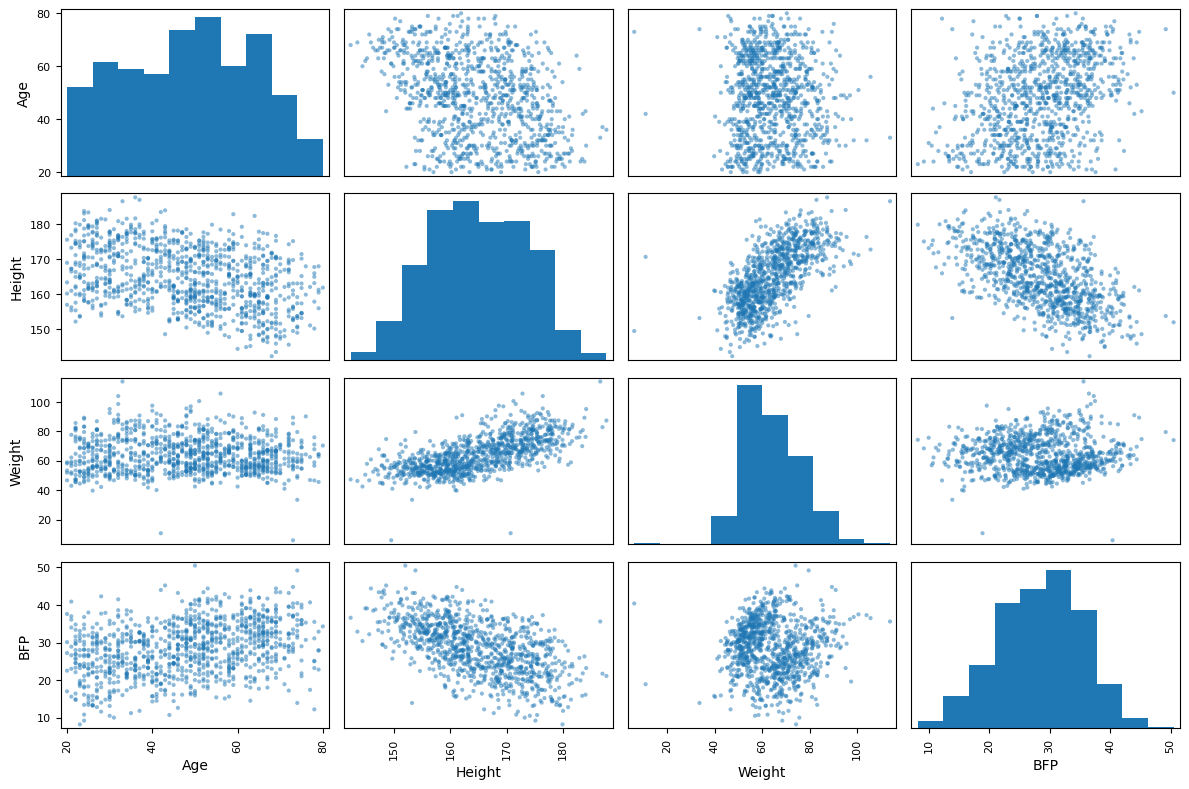

In [14]:
from pandas.plotting import scatter_matrix

# 산점도 행렬 생성
axs = scatter_matrix(body_df.iloc[:, 1:], figsize=(12, 8))

# 플롯 간격 조정
plt.tight_layout()
plt.show()

:::{warning}
동일한 두 특성에 대한 산점도라 하더라도 축을 다르게 지정하면 산점도가 다르게 그려질 수 있음에 주의한다.
예를 들어, 키와 몸무게의 산점도에서 x-축에 키를 사용할 때와 몸무게를 사용할 때의 산점도가 많이 달라 보인다.
하지만 두 특성 사이의 상관계수는 축 지정과 무관하게 동일하다.
:::

**데이터프레임의 `corr()` 메서드**

데이터프레임의 `corr()` 메서드는 수치형 특성들 사이의 피어슨 상관계수를 일괄 계산한다.

In [15]:
body_df.corr(numeric_only=True)

,Age,Height,Weight,BFP
Age,1.000000,-0.368255,-0.038761,0.337647
Height,-0.368255,1.000000,0.658913,-0.569835
Weight,-0.038761,0.658913,1.000000,-0.001381
BFP,0.337647,-0.569835,-0.001381,1.000000


:::{note} 상관계수와 자유도

상관계수는 자유도(ddof)에 영향을 받지 않는다.
이유는 상관계수의 분모와 분자에 자유도가 동일하게 영향을 주어 약분되어 사라지기 때문이다.
:::

피어슨 상관계수는 단위 또는 척도가 변경되더라도 달라지지 않는다.
아래 코드는 키 특성에 대해 표준화를 진행한다.

In [16]:
height_col = body_df[['Height']]
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)

body_df_copy = body_df.copy()
body_df_copy['Height_z'] = height_z
body_df_copy.head()

,Sex,Age,Height,Weight,BFP,Height_z
ID,,,,,,
F001,F,37.0,161.4,62.9,32.8,-0.399298
F002,F,26.0,168.1,56.1,31.5,0.384855
F003,F,39.0,163.4,53.2,25.2,-0.165222
F004,F,30.0,164.1,49.4,21.8,-0.083296
F005,F,44.0,152.9,51.9,24.2,-1.394118


표준화를 통해 키 특성값의 척도를 다르게 하더라도 다른 특성들과의 상관계수가 달라지지 않는다.

In [17]:
body_df_copy.corr(numeric_only=True).loc[['Height', 'Height_z']]

,Age,Height,Weight,BFP,Height_z
Height,-0.368255,1.0,0.658913,-0.569835,1.0
Height_z,-0.368255,1.0,0.658913,-0.569835,1.0


### 상관관계 히트맵

`seaborn` 라이브러리의 `sns.heatmap()` 함수는
특성들 사이의 피어슨 상관계수를
수치에 따른 색을 입힌 행렬로 표현하여
특성들 사이의 선형 상관관계를 보다 직관적으로 보여준다.

예를 들어, 아래 코드는 나이, 키, 몸무게, 체지방률 사이의 임의의 두 특성 사이의
상관계수를 히트맵으로 보여준다.
히트맵에 사용된 각 항목은 두 특성 사이의 상관계수이며,
값이 1에 가까울 수록 빨간색이,
-1에 가까울 수록 파란색이 강해지며,
무상관 경향이 클 수록 색이 옅어지도록 설정되어 있다.

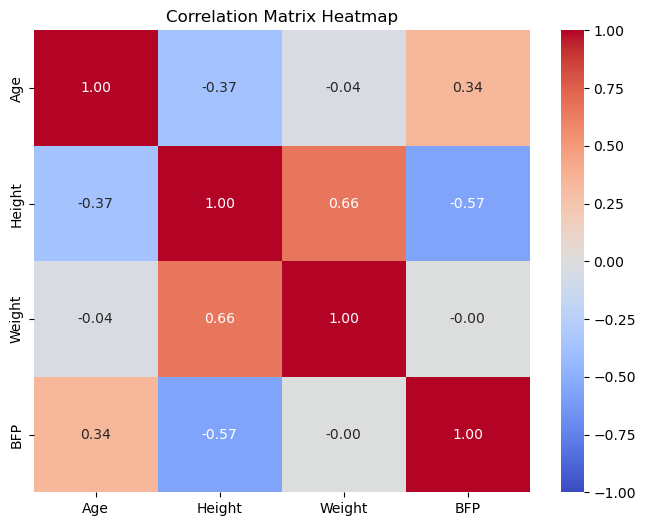

In [18]:
import seaborn as sns

corr_matrix = body_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,        # 각 셀에 실제 데이터(상관계수) 값 표시 여부
            cmap='coolwarm',   # 색상 맵 지정 (파란색에서 빨간색으로 변하는 색상)
            fmt='.2f',         # 셀 안의 숫자 표시 형식 지정 (소수점 둘째 자리까지)
            vmin=-1,           # 색막대의 최솟값 지정 (상관계수의 최솟값인 -1)
            vmax=1)            # 색막대의 최댓값 지정 (상관계수의 최댓값인 1)

plt.title('Correlation Matrix Heatmap')
plt.show()

상관관계가 대각선을 기준으로 대칭이고, 
대각선상에는 모두 1만 사용되기에 아랫쪽 삼각형 영역만 히트맵으로 보여주어도 충분하다.

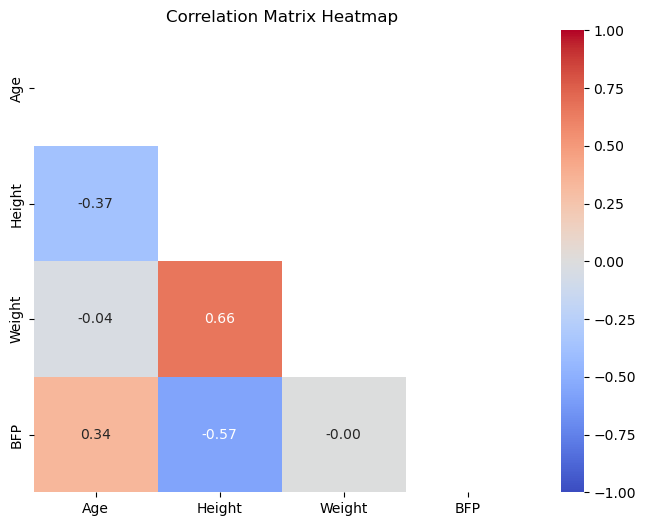

In [19]:
import seaborn as sns

corr_matrix = body_df.corr(numeric_only=True)

# 대각선 포함 위쪽 삼각형 영역 마스킹
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            vmin=-1, 
            vmax=1, 
            mask=mask)

plt.title('Correlation Matrix Heatmap')
plt.show()

## 앤스콤 콰르텟

피어슨 상관계수는 한두 개의 이상치에 매우 민감하게 반응할 수 있다.
따라서 데이터 분포를 요약한 대푯값(평균/분산/상관계수 등) 수치만 보고
데이터를 평가하면 실무에서 큰 재앙을 초래할 수 있기에
데이터 시각화 등 다른 기법을 함께 적용하여 데이터 분석을 진행해야 한다.

예를 들어, 데이터의 시각적 분포가 얼마나 중요한가를 증명한 유명한 사례인 앤스콤 콰르텟 (Anscombe's Quartet, 1973) 데이터를 살펴본다.

**데이터 불러오기**

앤스콤 콰르텟 데이터셋은 여러 인터넷 사이트에서 다운로드 할 수 있는데 형식이 조금씩 다르다.
아래 코드는 각각 두 개의 특성 `xi`와 `yi`로 구성된 4개의 데이터를
한꺼번에 불러온다.

In [20]:
anscombe = pd.read_csv(data_url + "anscombe.csv")
anscombe.head()

,x1,x2,x3,x4,y1,y2,y3,y4
0,10,10,10,8,8.04,9.14,7.46,6.58
1,8,8,8,8,6.95,8.14,6.77,5.76
2,13,13,13,8,7.58,8.74,12.74,7.71
3,9,9,9,8,8.81,8.77,7.11,8.84
4,11,11,11,8,8.33,9.26,7.81,8.47


네 쌍 `(x1, y1), (x2, y2), ... (x4, y4)` 각각에 대한 평균, 분산, 상관계수는
모두 동일하다.
하지만 시각화를 하면 네 개의 데이터의 분포 형태가 완전히 다르다.

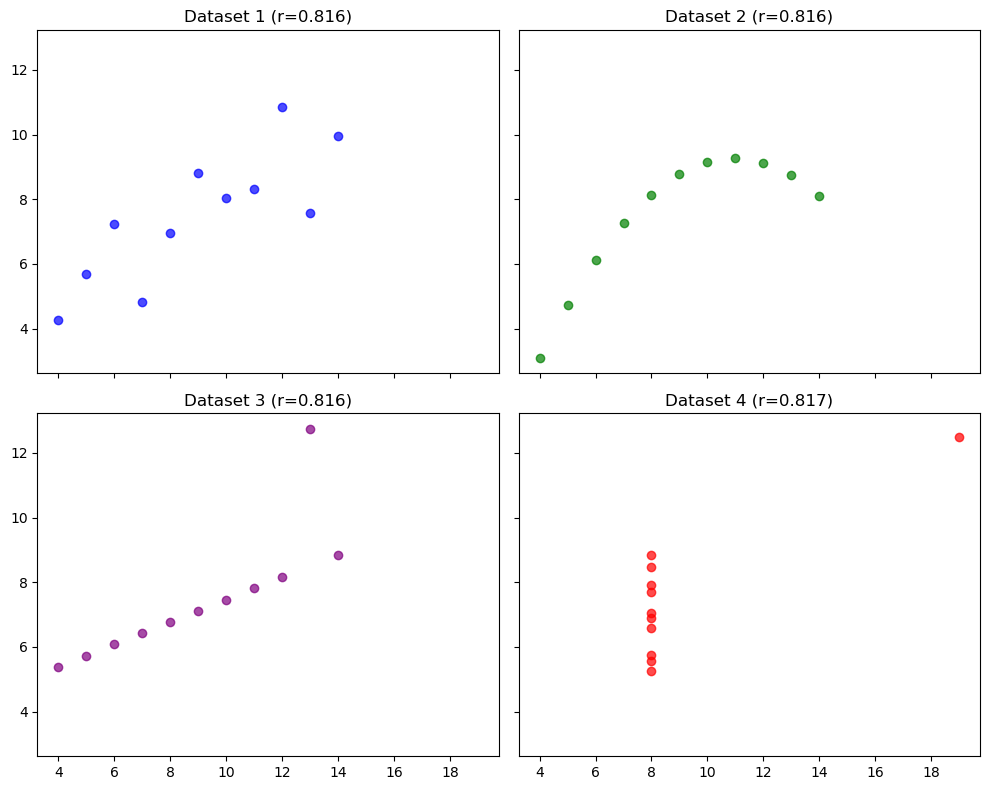

In [21]:
# 2행 2열 멀티 차트 서브플롯 준비
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

# Dataset 1
ax[0, 0].scatter(anscombe['x1'], anscombe['y1'], color='blue', alpha=0.7)
ax[0, 0].set_title(f"Dataset 1 (r={anscombe['x1'].corr(anscombe['y1']):.3f})")

# Dataset 2
ax[0, 1].scatter(anscombe['x2'], anscombe['y2'], color='green', alpha=0.7)
ax[0, 1].set_title(f"Dataset 2 (r={anscombe['x2'].corr(anscombe['y2']):.3f})")

# Dataset 3
ax[1, 0].scatter(anscombe['x3'], anscombe['y3'], color='purple', alpha=0.7)
ax[1, 0].set_title(f"Dataset 3 (r={anscombe['x3'].corr(anscombe['y3']):.3f})")

# Dataset 4
ax[1, 1].scatter(anscombe['x4'], anscombe['y4'], color='red', alpha=0.7)
ax[1, 1].set_title(f"Dataset 4 (r={anscombe['x4'].corr(anscombe['y4']):.3f})")

plt.tight_layout()
plt.show()

:::{note}
`plt.subplots()` 함수는 Figure와 Axes 객체를 동시에 생성하며, `nrows`와 `ncols` 매개변수로 여러 서브플롯을 격자 형태로 배치할 수 있다.
자세한 활용법은 이어지는 장(chapter)에 설명한다.
:::

놀랍게도 4개 데이터 쌍의 피어슨 상관계수는 모두 0.816으로 정확히 동일하며, 단순 산술 수치로만 보면 "서로 꽤 강한 양의 선형 상관관계"로 오판할 것이다. 하지만 시각화 결과는 완전히 다르다.

- 데이터 1: 기본적인 선형 상관관계의 모습을 갖추고 있다.
- 데이터 2: 비선형 상관관계(곡선 형태)이기 때문에 단순 피어슨 상관계수로 요약하는 것은 부적절하다.
- 데이터 3: 기본적으로 상관계수가 1인 완벽한 직선형이지만, 단 한 개의 이상치(Outlier)가 상관계수를 작게 만들었다.
- 데이터 4: x-좌표는 기본적으로 변화가 없어서 상관계수가 원래 0이어야 하는데, 하나의 이상치로 인해 피어슨 상관계수가 매우 커졌다.

## 심슨의 역설

같은 맥락에서 **심슨의 역설**<font size='2'>Simpson's paradox</font>은 전체 데이터를 두고 본 상관관계와,
그룹별(제3의 변수)로 나누어 본 상관관계가 완전히 다르게(역전되어) 나타나는 현상을 말한다.
설명을 위해 파머 펭귄(Palmer Penguin) 데이터셋을 예제로 활용한다.

**파머 펭귄 데이터셋**

파머 펭귄(Palmer Penguins) 데이터셋은 남극 파머 군도(Palmer Archipelago)의 Biscoe, Dream, Torgersen 세 개의 섬에 서식하는
세 종의 펭귄(Adelie, Chinstrap, Gentoo)을 대상으로, 크리스틴 고먼(Kristen Gorman)이 2007년부터 2009년까지 수집한 신체 측정 데이터를 담고 있다.

<div align="center"><img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/Palmer_archipelago.jpg?raw=true" width="400px"></div>

<p><div style="text-align: center">&lt;그림 출처: <a href="https://ko.wikipedia.org/wiki/파머_군도">(위키백과) 파머 군도</a>&gt;</div></p>

**데이터셋 불러오기**

이 데이터셋은 Seaborn 라이브러리에서 기본으로 제공하며, 총 344마리의 펭귄의 
종(species), 서식지(island), 부리 길이(bill length, mm), 부리 깊이 혹은 두께(bill depth, mm), 날개 길이(flipper length, mm), 몸무게(body mass, g), 성별(sex) 등 
총 7개의 특성(Feature) 데이터로 구성된다.

In [22]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**결측치 처리**

부리와 날개 특성에 2개, 성별 특성에 11개의 결측치가 포함되어 있다.

In [23]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


결측치가 많지 않다. 그리고 부리와 날개의 특성에 동일하게 2개씩 결측치가 존재하기에 어떤 형식으로 결측치가 존재하는지 확인해본다.
결측치가 하나로도 포함된 행을 필터링하기 위한 마스크를 정의하기 위해 `isna()`와 `any()` 메서드를 연속해서 적용한다.

In [28]:
na_rows_mask = penguins.isna().any(axis=1)
penguins[na_rows_mask]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


3번과 339번 행의 샘플에 부리, 날개, 성별 정보가 모두 없다.
이런 경우 두 가지 중에 하나 선택할 수 있다.

- 선택 1: 부리, 날개 특성은 각 특성의 평균값으로 대체.
- 선택 2: 결측치가 많지 않기에 결측치를 하나라도 포함한 모든 샘플 삭제

여기서는 선택 2를 활용한다. 
2개의 부리, 날개 특성은 특성 평균값으로 대체할 수도 있지만 문제는 성별 정보도 함께 결측치인 게 문제다.
성별 정보를 임의로 채우는 일은 적절해보이지 않는다.

아래 코드는 결측치가 포함된 모든 샘플을 제거해서 총 333개의 데이터 샘플만 남긴다.

In [24]:
penguins = penguins.dropna()
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


**종과 서식지 확인**

데이터셋에 포함된 펭귄은 Adelie, Gentoo, Chinstrap 세 종으로 구분되었다.

In [25]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

<div align="center"><img src="https://github.com/codingalzi/code-workout-datasci/blob/master/images/palmer-penguins.jpg?raw=true" width="500px"></div>

<p><div style="text-align: center">&lt;그림 출처: <a href="https://education.rstudio.com/blog/2020/07/palmerpenguins-cran/">(RStudio Education) Release the penguins</a>&gt;</div></p>

펭귄의 서식지는 Biscoe, Dream, Torgersen 3개의 섬으로 확인된다.

In [26]:
penguins['island'].value_counts()

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

**부리 길이 vs 부리 두께**

펭귄의 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`) 사이의 관계를 살펴본다.

Seaborn 라이브러리의 `regplot()` 함수는 산점도 위에 선형 회귀선을 함께 그려 두 특성 사이의 상관관계 경향을 직관적으로 파악할 수 있게 해준다.
선형 회귀선은 데이터 포인트들의 분포를 가장 잘 설명하는 직선으로, 두 변수 간의 선형적 관계를 요약한다.

이 직선의 기울기가 양수이면 두 변수가 함께 증가하는 양의 상관관계를, 음수이면 한 변수가 증가할 때 다른 변수가 감소하는 음의 상관관계를 나타낸다.
또한 `regplot()`은 회귀선 주변에 95% 신뢰 구간을 음영으로 표시하여, 추정된 회귀선의 불확실성 범위를 함께 시각화해준다.

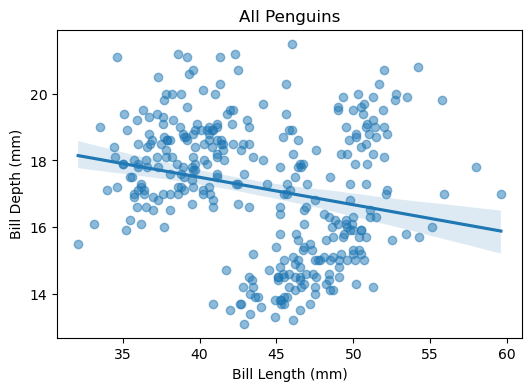

In [27]:
plt.figure(figsize=(6, 4))

# 부리 길이와 두께의 산점도 및 선형 회귀선
sns.regplot(data=penguins, 
            x="bill_length_mm",       # x축: 부리 길이
            y="bill_depth_mm",        # y축: 부리 두께
            scatter_kws={'alpha':0.5} # 산점도의 점 투명도 조절 (alpha=0.5)
            )

plt.title("All Penguins")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

위 그림에서 볼 수 있듯, 모든 펭귄 데이터를 하나로 묶어놓고 보면 부리가 길어질수록 두께는 얇아지는 명확한 음(-)의 상관관계를 갖는 것처럼 보인다.
상관계수를 실제로 계산하면 -0.23 정도이다.

In [28]:
penguins[['bill_length_mm', 'bill_depth_mm']].corr()

,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.228626
bill_depth_mm,-0.228626,1.000000


반면에 종별로 산점도를 그리면 부리 길이와 두께 사이의 상관관계가 완전히 달라 보인다.
Seaborn 라이브러리의 `lmplot()` 함수는 산점도와 선형 회귀선을 함께 시각화하는 함수로, 
`hue`, `col`, `row` 등의 매개변수를 통해 범주형 변수에 따라 데이터를 색상이나 서브플롯으로 분리하여 
그룹별 회귀 관계를 한눈에 비교할 수 있게 해준다.

<Figure size 800x600 with 0 Axes>

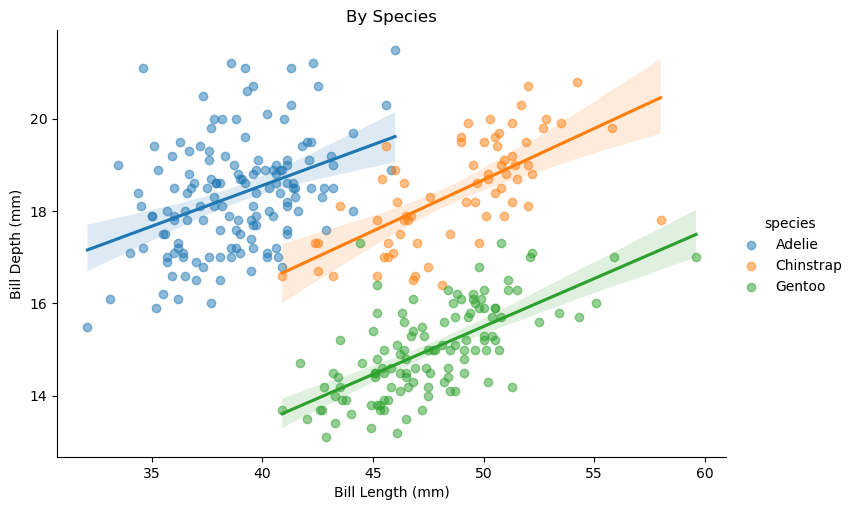

In [29]:
plt.figure(figsize=(8, 6))

sns.lmplot(data=penguins, 
           x="bill_length_mm",       # x축: 부리 길이
           y="bill_depth_mm",        # y축: 부리 두께
           hue="species",            # 종별로 색상 구분
           height=5,                 # 그래프 높이
           aspect=1.5,               # 그래프 가로 세로 비율
           scatter_kws={'alpha':0.5} # 산점도 점의 투명도 설정
           )

plt.title("By Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

아래 코드를 실행하면 
종(`species`)별로 그룹화한 후 `bill_length_mm`과 `bill_depth_mm` 두 특성 간의 피어슨 상관계수를 계산된다.
펭귄의 종(`species`)을 통제(고정)하고 나누어서 분석하니, 모든 종에 있어서 부리가 길어질수록 두께도 늘어나는 확고한 양(+)의 상관관계를 보인다.
종(`species`)과 같은 **교란 변수**<font size='2'>confounding variable</font>를 무시한 채
상관계수를 구했을 때와 정반대의 결론에 도달하는 현상을 통계학에서 **심슨의 역설**이라 부른다. 

In [127]:
penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()

bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.385813
          bill_depth_mm         0.385813       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.654023
          bill_depth_mm         0.654023       1.000000

결과는 `species`와 특성 이름의 두 계층으로 구성된 다중 인덱스를 행 인덱스로 갖는 데이터프레임으로 반환된다.

- 1계층: `Adelie`, `Chinstrap`, `Gentoo` 등 종(`species`)
- 2계층: `bill_length_mm`, `bill_depth_mm` 등 열 특성

다중 인덱스를 사용하는 행 또는 열에 대한 인덱싱은 인덱스로 구성된 튜플을 사용하면 된다.
예를 아래 코드는 Adelie 종의 부리 길이와 두께의 상관계수를 확인한다.

In [132]:
df_double_index = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
df_double_index.loc[('Adelie', 'bill_length_mm'), 'bill_depth_mm']

np.float64(0.3858132004955786)

:::{note} 교란 변수
**교란 변수**(confounding variable) 란 두 변수(데이터) 모두에 영향을 미쳐 두 변수 사이의 관계를 왜곡하는 제3의 변수이다.

위 펭귄 데이터를 예로 들면, `bill_length_mm`과 `bill_depth_mm` 사이의 관계를 분석할 때 종(`species`) 이 교란 변수로 작용한다.
종을 고려하지 않으면 음의 상관관계가 나타나지만, 종별로 분리하면 양의 상관관계가 나타나는 것이 그 증거이다.
:::

## 연습문제

**문제 1: 심슨의 역설 사례 찾기**

성인 남녀 1,000명(여성 500명, 남성 500명)의 신체 정보를 담고 있으며, 6개의 특성 데이터로 구성된
`body_fat.csv` 파일에서 심슨의 역설 사례를 찾아서 설명하라.

답:

심슨의 역설 사례를 찾기 위해 신체 정보 데이터셋 전체를 활용했을 때의 상관계수와 
성별로 그룹을 지었을 때의 상관계수를 확인한다.

- 전체 데이터셋 활용

In [103]:
body_df.corr(numeric_only=True)

,Age,Height,Weight,BFP
Age,1.000000,-0.368255,-0.038761,0.337647
Height,-0.368255,1.000000,0.658913,-0.569835
Weight,-0.038761,0.658913,1.000000,-0.001381
BFP,0.337647,-0.569835,-0.001381,1.000000


- 성별 데이터셋 활용

In [102]:
body_df.groupby('Sex').corr(numeric_only=True)

Age    Height    Weight       BFP
Sex                                               
F   Age     1.000000 -0.517697  0.151228  0.409435
    Height -0.517697  1.000000  0.164666 -0.407790
    Weight  0.151228  0.164666  1.000000  0.566064
    BFP     0.409435 -0.407790  0.566064  1.000000
M   Age     1.000000 -0.509665 -0.108904  0.308942
    Height -0.509665  1.000000  0.381675 -0.277947
    Weight -0.108904  0.381675  1.000000  0.497619
    BFP     0.308942 -0.277947  0.497619  1.000000

다음 두 사례가 성별(Sex)이라는 교란 변수를 통제하기 전과 후의 결과가 달라지는 심슨의 역설에 해당한다.

1. 나이(Age)와 몸무게(Weight)
    - 전체 상관계수: -0.038761 (선형 상관관계 미약)
    - 여성 상관계수: 0.151228  (약한 양의 상관관계)
    - 남성 상관계수: -0.108904  (약한 음의 상관관계)
2. 몸무게(Weight)와 체지방률(BFP)
    - 전체 상관계수: -0.001381 (선형 상관관계 미약)
    - 여성 상관계수: 0.566064  (뚜렷한 양의 상관관계)
    - 남성 상관계수: 0.497619  (뚜렷한 양의 상관관계)

**💡 결론:**
몸무게와 체지방률의 경우 전체 데이터를 하나로 묶어서 분석하면 두 변수 간에 아무런 상관관계가 없는 것처럼 보이지만,
성별(Sex)로 그룹을 나누어 분석하면 각 그룹 내에서는 뚜렷한 양의 상관관계가 나타난다.
이를 통해 데이터를 분석할 때 숨겨진 교란 변수(위 사례의 경우 '성별')를 고려하는 것이 매우 중요함을 알 수 있다.

시각화 하면 심슨의 역설이 더욱 뚜렷하게 보인다.

- 몸무게(Weight)와 체지방률(BFP)의 상관관계

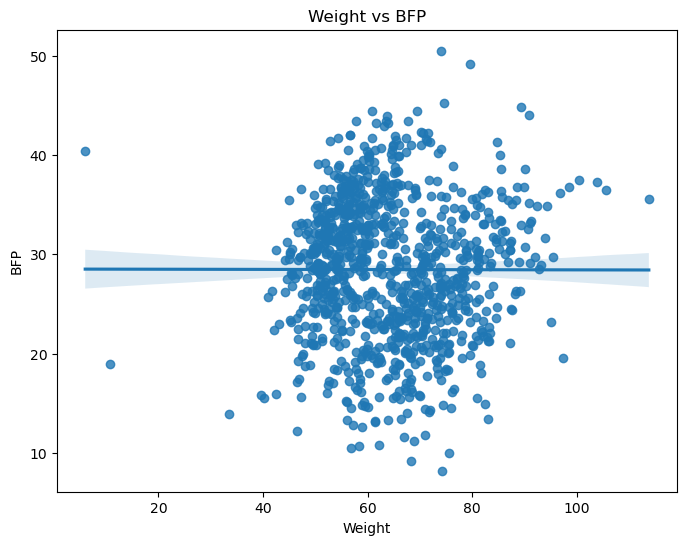

In [124]:
plt.figure(figsize=(8, 6))
sns.regplot(data=body_df, x='Weight', y='BFP')
plt.title("Weight vs BFP")
plt.show()

- 성별 몸무게(Weight)와 체지방률(BFP)의 상관관계

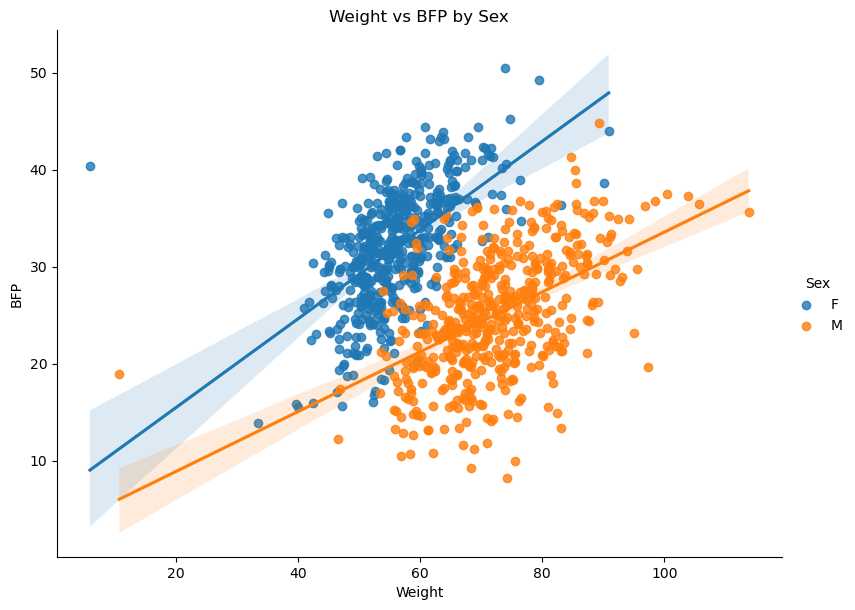

In [126]:
sns.lmplot(data=body_df, x='Weight', y='BFP', hue='Sex', height=6, aspect=8/6)
plt.title("Weight vs BFP by Sex")
plt.show()

**문제 2: 파머 펭귄 데이터셋의 선형 상관관계**

(1) `penguins` 데이터프레임에 포함된 특성들 중에 강한 양의 선형 상관관계를 갖는 두 특성의 산점도를 그려라.

답:

날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)게 강한 양의 선형 상관관계를 보인다.

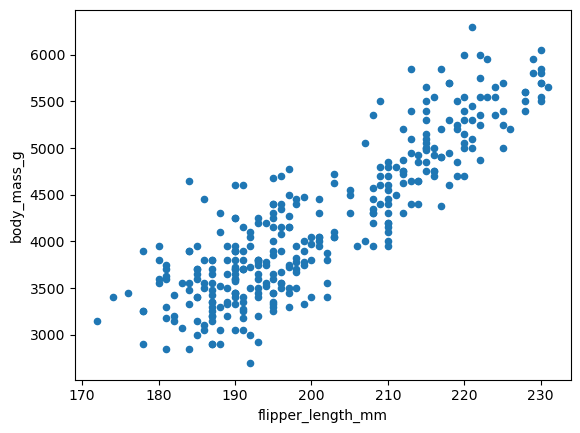

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna() # 결측치 제거

penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g')
plt.show()

(2) `penguins` 데이터프레임에 포함된 특성들 중에 강한 음의 선형 상관관계를 갖는 두 특성의 산점도를 그려라.

답:

날개 길이(`flipper_length_mm`)와 부리 두께(`bill_depth_mm`)가 강한 음의 선형 상관관계를 보인다.

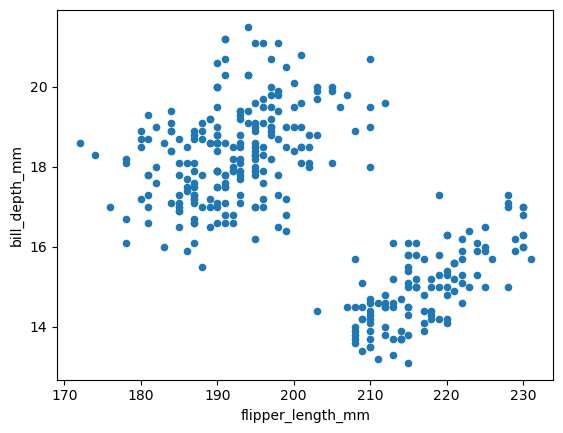

In [76]:
penguins.plot.scatter(x='flipper_length_mm', y='bill_depth_mm')
plt.show()

(3) 부리 길이와 날개 길이 사이의 공분산을 계산하라.

답:

데이터프레임의 `cov()` 메서드를 활용한다.

In [95]:
penguins[['flipper_length_mm', 'bill_length_mm']].cov(ddof=0)

,flipper_length_mm,bill_length_mm
flipper_length_mm,195.851762,49.907870
bill_length_mm,49.907870,29.816525


시리즈의 `cov()` 메서드를 활용하는 방식도 가능하다.

In [96]:
penguins['flipper_length_mm'].cov(penguins['bill_length_mm'], ddof=0)

np.float64(49.90787003219434)

(4) 길이와 두께의 현재 단위는 밀리미터(mm)이다. 부리와 날개의 길이를 센티미터(cm)로 변환한 다음에 공분산을 확인하라.

답:

부리의 현재 길이를 10으로 나누면 센티미터(cm) 단위로 변환된다.

In [93]:
penguins_scaled = penguins.copy()
penguins_scaled['flipper_length_cm'] = penguins_scaled['flipper_length_mm'] / 10
penguins_scaled['bill_length_cm'] = penguins_scaled['bill_length_mm'] / 10

변환 후 날개 길이와 부리 길이와의 공분산은 49.9에서 0.5 정도로 줄어들었다.

In [97]:
penguins_scaled['flipper_length_cm'].cov(penguins_scaled['bill_length_cm'])

np.float64(0.5005819494192988)

(5) `penguins` 데이터프레임에 포함된 모든 수치형 특성들 사이의 상관관계를 산점도 행렬을 통해 한꺼번에 확인하라.

답:

`scatter_matrix()` 함수는 데이터프레임이 포함된 모든 수치형 특성들을 활용한 산점도를 그린다.

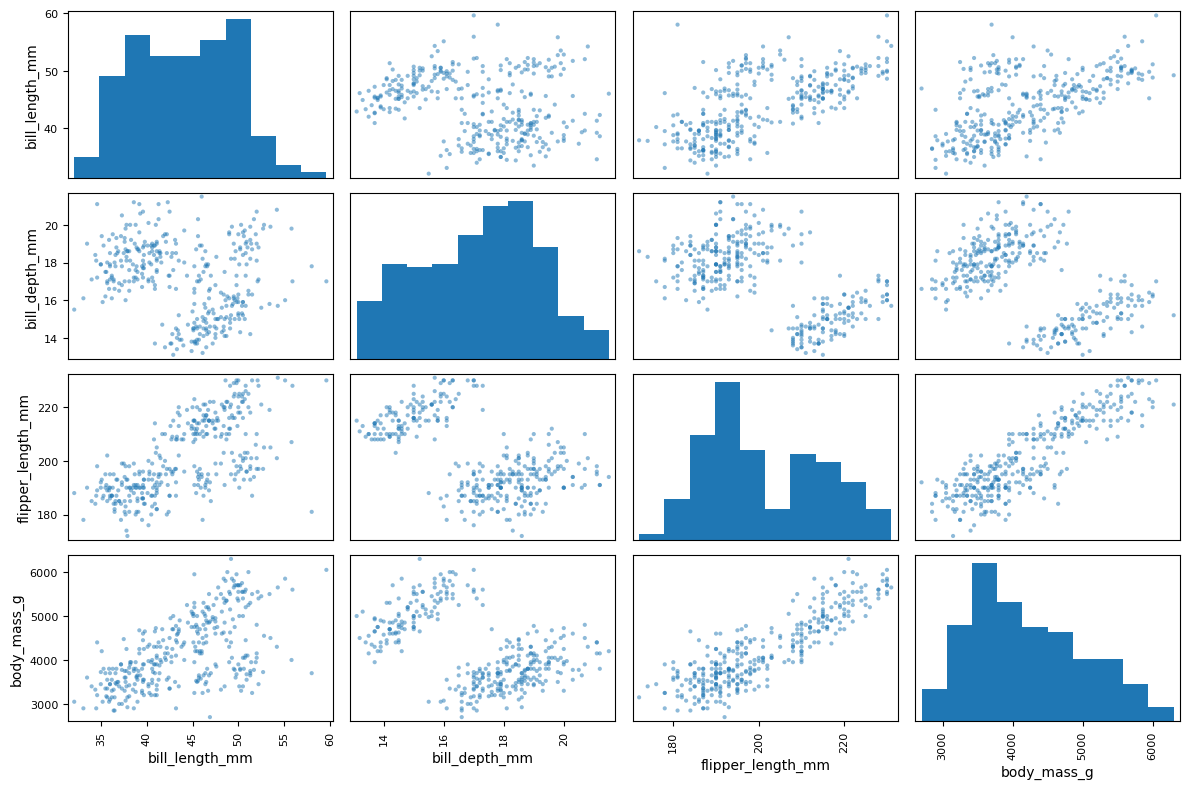

In [84]:
from pandas.plotting import scatter_matrix

axs = scatter_matrix(penguins, figsize=(12, 8))
plt.tight_layout()
plt.show()

(6) `penguins` 데이터프레임에 포함된 수치형 특성들 사이의 피어슨 상관계수를 일괄 계산하라.

답:

데이터프레임의 `corr()` 메서드를 실행할 때 `numeric_only=True` 키워드 인자를 지정한다.

In [ ]:
penguins.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


(7) 날개 길이 특성에 대해 표준화를 진행한 다음에 다른 특성들과의 상관계수가 달라지지 않음을 확인하라.

답:

표준화된 날개 길이 특성을 먼저 데이터프레임 사본에 추가한다.

In [99]:
flipper_col = penguins[['flipper_length_mm']]
flipper_z = (flipper_col - flipper_col.mean()) / flipper_col.std(ddof=0)

penguins_copy = penguins.copy()
penguins_copy['flipper_z'] = flipper_z
penguins_copy.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,flipper_z
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,-1.426752
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,-1.069474
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,-0.426373
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,-0.569284
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,-0.783651


표준화를 통해 척도를 다르게 하더라도 다른 특성들과의 상관계수가 달라지지 않는다.

In [100]:
penguins_copy.corr(numeric_only=True).loc[['flipper_length_mm', 'flipper_z']]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,flipper_z
flipper_length_mm,0.653096,-0.577792,1.0,0.872979,1.0
flipper_z,0.653096,-0.577792,1.0,0.872979,1.0


(8) `penguins` 데이터프레임에 포함된 수치형 특성들 사이의 상관계수를 이용한 히트맵을 구현하라.
단, 아랫쪽 삼각형 영역만 히트맵으로 보여주어야 한다.

답:

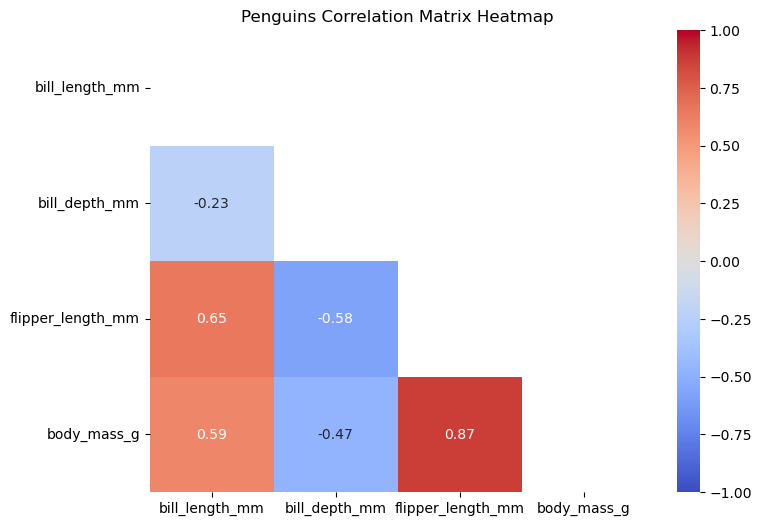

In [101]:
import seaborn as sns
import numpy as np

corr_matrix = penguins.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

**문제 3: 넘파이 어레이 활용 상관관계 분석**

넘파이 어레이만 활용하면서도 효율적으로 상관관계 분석을 진행할 수 있다.

문제 설정을 위해 기본 데이터 저장소에 있는 `sc_weir.csv` 파일을 활용한다.
이 데이터는 광주광역시에서부터 전라남도 나주를 거쳐 서해까지 이어지는 영산강에 설치된 승촌보에서 측정한 두 종류의 데이터를 담고 있다.

- `Chl-a`: 녹조 발생의 주요 요인인 클로로필-A 수치 100개
- `Discharge`: 보에서 방출되는 시간당 방류량 수치 100개

이 데이터를 수집한 목적은 클로로필-A의 농도와 보 방류량과의 상관관계를 확인하기 위함이다.
일반적으로 방류량이 많을수록 클로로필-A 농도는 떨어지며, 반대로 클로로필-A 농도가 높을수록 수질(water quality)이 나빠진다.

In [54]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


항목만으로 구성된 넘파이 어레이를 선언한다.

In [55]:
sc_weir_arr = sc_weir_df.values
sc_weir_arr.shape

(100, 2)

클로로필-A와 방류량 두 데이터를 별도의 어레이로 지정한다.

In [56]:
chl_a_arr = sc_weir_arr[:, 0]
discharge_arr = sc_weir_arr[:, 1]

(1) 클로로필-A와 시간당 방류량 사이의 공분산을 계산하고 두 데이터 사이의 상관관계를 설명하라.

답:

2차원 어레이 `sc_weir_arr`에 포함된 열들 사이의 공분산을 계산하기 위해 `rowvar=False` 키워드 인자를 지정하고,
편차 자유도를 0으로 설정(`ddof=0`)하여 공분산 행렬을 계산한다.

In [57]:
np.cov(sc_weir_arr, rowvar=False, ddof=0)

array([[506.8004, -66.2198],
       [-66.2198,  40.2851]])

(2) 클로로필-A와 시간당 방류량 사이의 피어슨 상관계수를 계산하고 두 데이터 사이의 선형 상관관계를 설명하라.

답:

공분산의 경우처럼 `rowvar=False`로 지정하면서 `np.corrcoef()` 함수를 활용한다.

In [58]:
np.corrcoef(sc_weir_arr, rowvar=False)

array([[ 1.       , -0.4634439],
       [-0.4634439,  1.       ]])

(3) x-축을 방류량, y-축을 클로로필-A 수치로 지정한 다음 산점도를 그린다.

답:

아래 코드에서 `plt.scatter()` 함수는
`sc_weir_arr`의 두 번째 열(방류량)을 x-축, 첫 번째 열(클로로필-A)을 y-축으로 하는 산점도를 그린다.

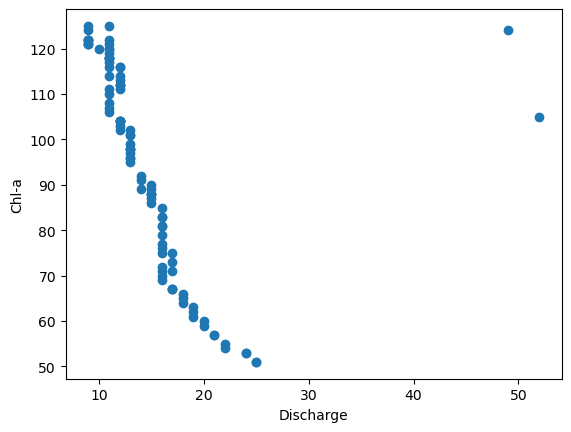

In [59]:
plt.scatter(sc_weir_arr[:, 1], sc_weir_arr[:, 0])

# 그래프 설정
plt.xlabel("Discharge")
plt.ylabel("Chl-a")    
plt.show()

(4) 위 산점도에 따르면 두 개의 이상치가 존재한다.
어떤 데이터가 이상치인지 설명하라.

답:

- 산점도 오른쪽 상단에 위치한 두 점이 이상치로 보인다.

- 이유: 두 점을 제외하면 방류량이 많아질 수록 클로로필-A 농도가 떨어진다. 
    하지만 두 점은 방류량이 무엇보다도 높지만 클로로필-A 농도가 매우 높다.

(5) 클로로필-A 데이터와 방수량 두 데이터셋 모두에서 이상치에 해당하는 두 개의 값이 제거된 어레이를 가리키는 `sc_weir_no_outliers` 변수를 정의하라.

답:

두 개의 이상치 모두 방류량이 40을 초과한 경우에 해당한다.
따라서 부울 인덱싱을 적용하여 이상치를 확인할 수 있다.

In [60]:
mask = discharge_arr > 40
sc_weir_arr[mask]

array([[105,  52],
       [124,  49]])

마스크를 반대로 적용하면 이상치가 제거된 데이터만 남는다.

In [63]:
sc_weir_no_outliers = sc_weir_arr[~mask]

(6) 이상치를 제거한 두 데이터셋을 이용하여 산점도를 다시 그려본다.

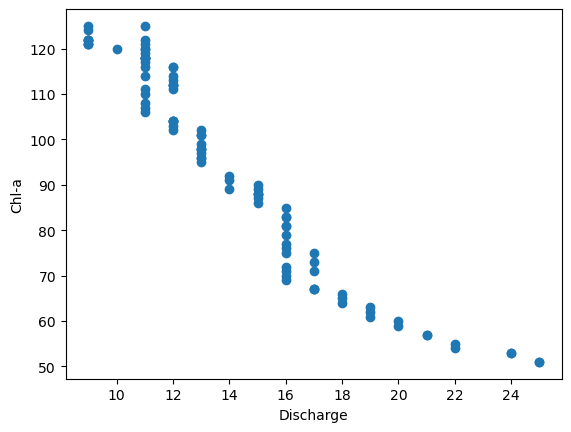

In [64]:
plt.scatter(sc_weir_no_outliers[:, 1], sc_weir_no_outliers[:, 0])

# 그래프 설정
plt.xlabel("Discharge")
plt.ylabel("Chl-a")    
plt.show()

(7) 이상치를 제거하기 전과 후 클로로필-A와 방류량 데이터 사이의 상관계수를 비교하라.

답:

- 이상치 제거 전

In [69]:
np.corrcoef(sc_weir_arr, rowvar=False)[0, 1]

np.float64(-0.4634438968268776)

- 이상치 제거 후

In [70]:
np.corrcoef(sc_weir_no_outliers, rowvar=False)[0, 1]

np.float64(-0.9565347907790098)

결론: 선형 상관관계가 강화되었다.